**Heart Failure Prediction Model Prototype**

Dataset by(Kaggle) with sample size of 1190 patiens. Combined across 5 heart disease datasets: Cleveland, Hungarian, Switzerland, Long beach VA and statlog.

The dataset comprises several features : 
'Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [4]:
df = pd.read_csv(r'D:\BOOTCAMP 4 Months\Cardio ML\heart.csv')
print('shape:',df.shape)
print(df.columns)
#print(df.head(3))

shape: (918, 12)
Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')


In [5]:
print(df.dtypes)
print('Duplications :',df.duplicated().sum())

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object
Duplications : 0


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Text(0.5, 1.0, 'ChestPainType')

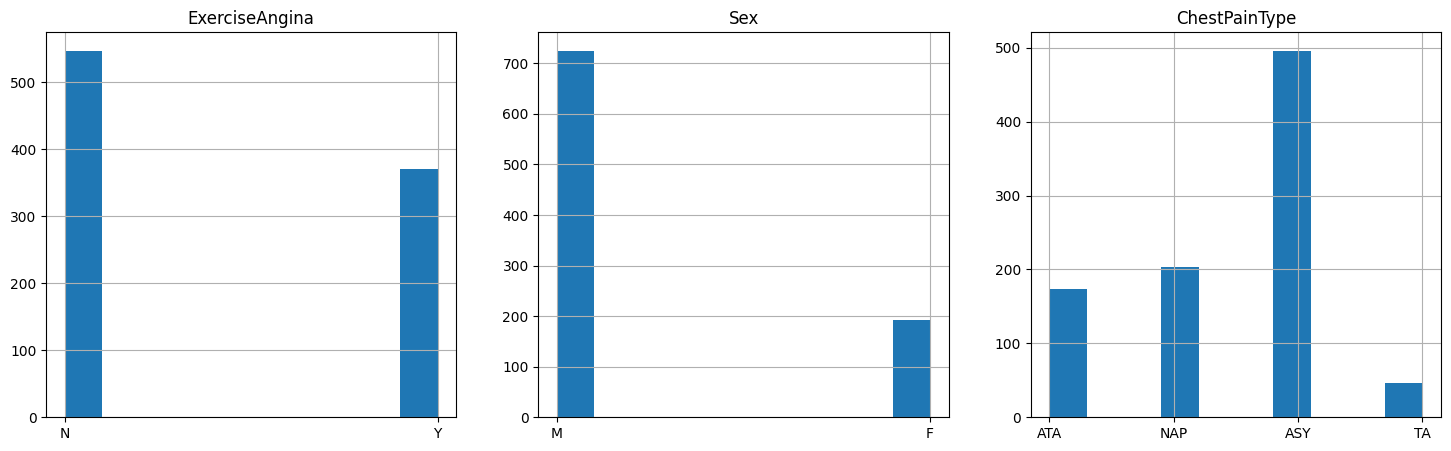

In [7]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
df['ExerciseAngina'].hist()
plt.title('ExerciseAngina')
plt.subplot(1,3,2)
df['Sex'].hist()
plt.title('Sex')
plt.subplot(1,3,3)
df['ChestPainType'].hist()
plt.title('ChestPainType')

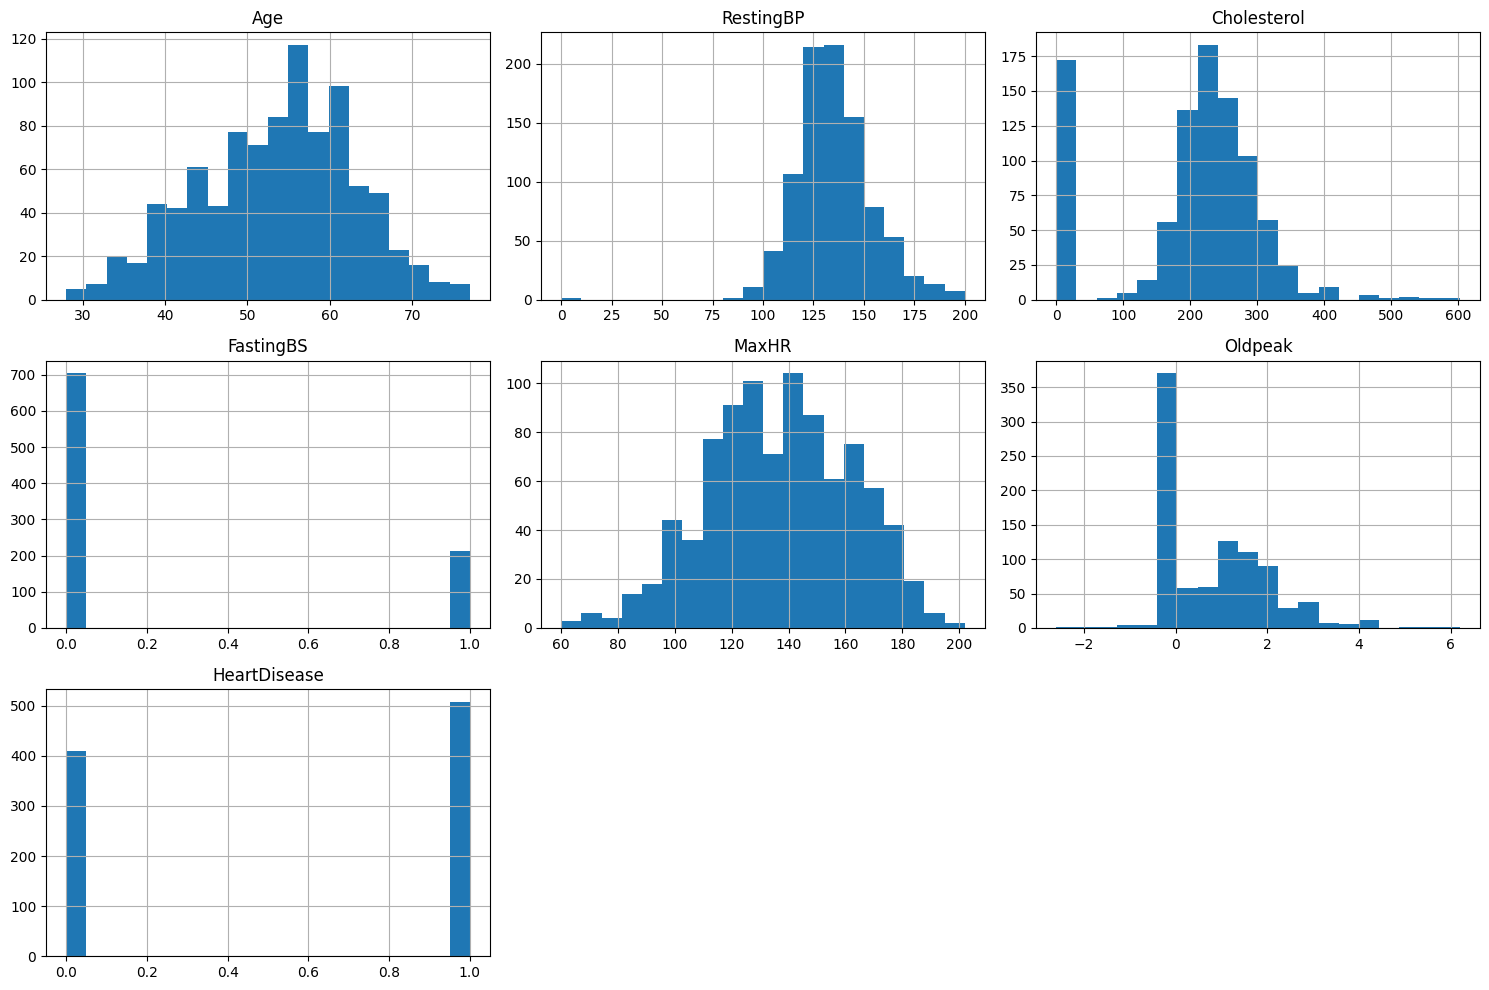

In [8]:
df.hist(
    figsize=(15,10),
    bins=20
)
plt.tight_layout()
plt.show()

<Axes: >

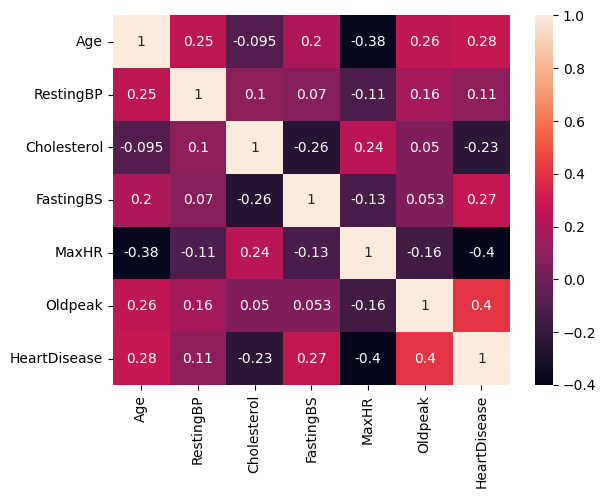

In [9]:
# Calculate correlation for numeric data only
numeric_correlation = df.corr(numeric_only=True)
sns.heatmap(numeric_correlation,annot=True)


**Correlation heatmap**

Strongest predictors of HeartDisease:

**Oldpeak**: 0.40 — the strongest positive correlation. Makes clinical sense: higher ST depression during exercise is a classic ischemia marker.

**MaxHR**: -0.40 — the strongest negative correlation. Also expected: lower peak heart rate under exertion often reflects reduced cardiac reserve or chronotropic incompetence.

**RestingBP**: 0.11 — weak. Surprising given resting BP is a textbook risk factor, but weak correlation in a bivariate sense doesn't rule out a role in a multivariate model.

**Cholesterol**: -0.23 — this one make me suspicious, not confident. A negative correlation between cholesterol and heart disease contradicts basic cardiology. This is very likely a data artifact, not a real signal.

**Between-feature relationships worth noting:**

**Age vs MaxHR:** -0.38 — physiologically expected (max HR declines with age), and this is your biggest multicollinearity concern between two predictors.
**Cholesterol vs FastingBS:** -0.26 — also counterintuitive on its face, another sign pointing to the same data issue.

**Histogram charts**

Here is where the heatmap weirdness gets explained

**Cholesterol:** Huge Spike (~170 patients) on value 0 mg/dl. This is almost certinly missing data encoded as 0 and not true zero level.

**RestingBP**: same pattern, smaller spike at 0.

**HeartDisease:** fairly balanced target (~410 vs ~510) — good news for modeling, no severe class imbalance to correct for.

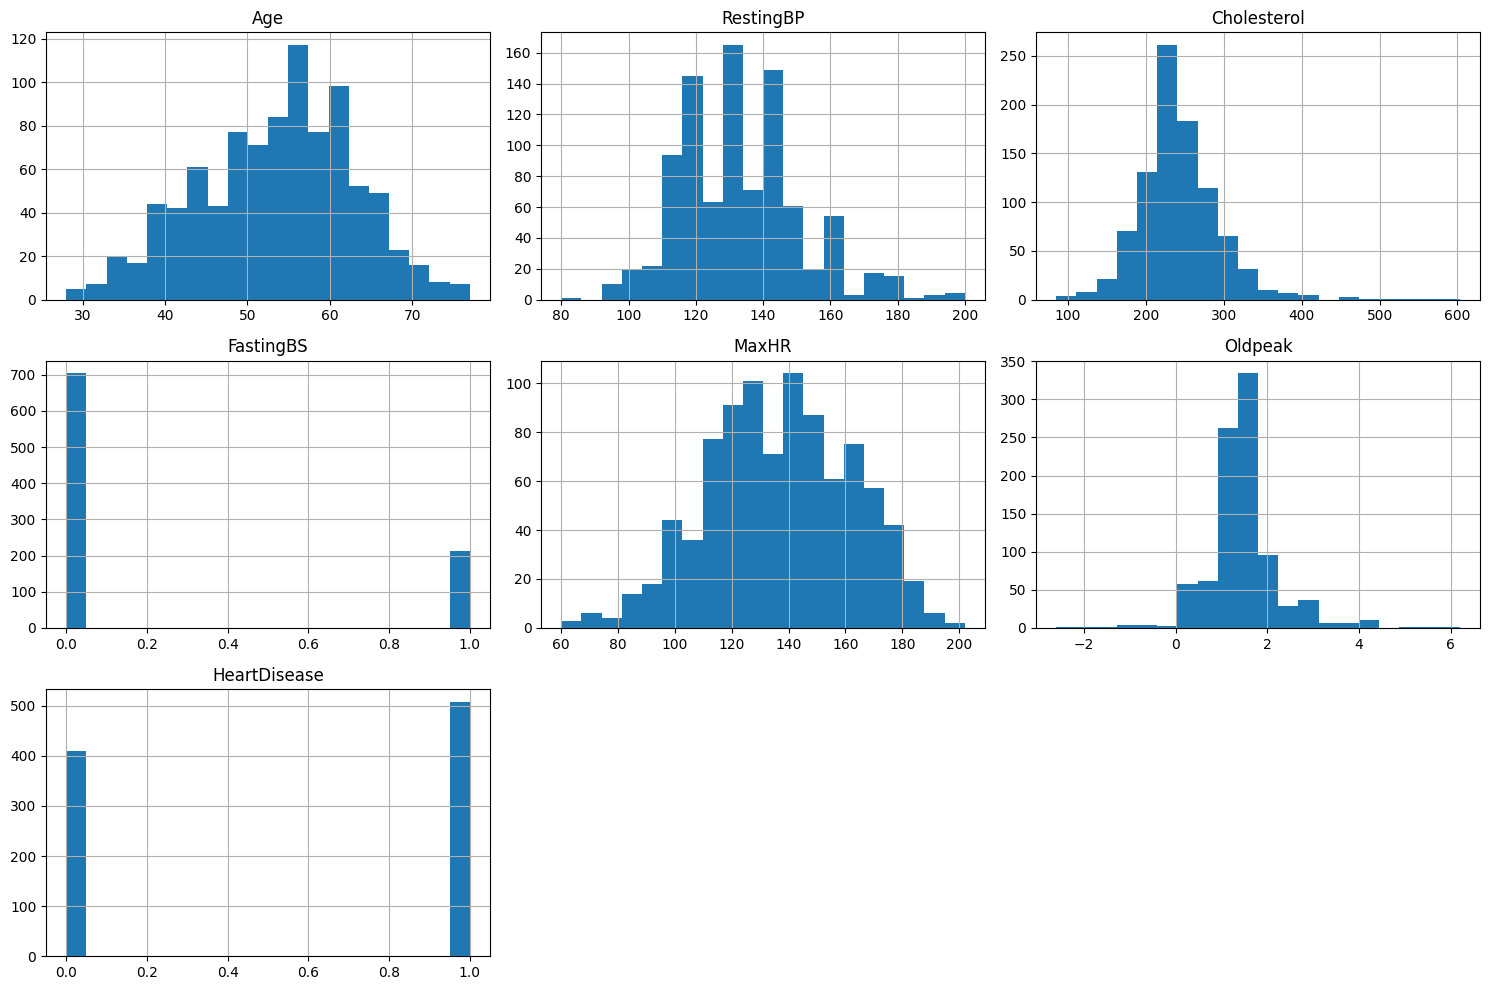

In [127]:
df.hist(
    figsize=(15,10),
    bins=20
)
plt.tight_layout()
plt.show()

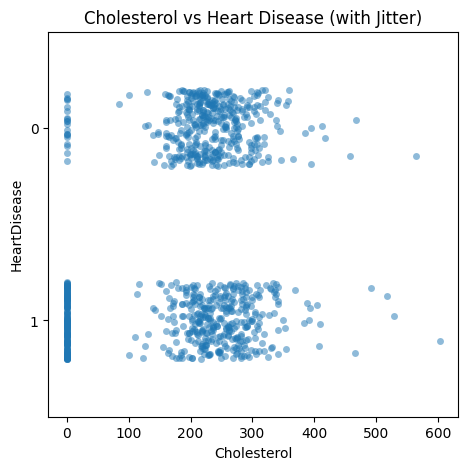

In [10]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
sns.stripplot(data=df, x='Cholesterol', y='HeartDisease', orient='h', jitter=0.2, alpha=0.5)
plt.title('Cholesterol vs Heart Disease (with Jitter)')
plt.show()

**Categorical variables encoding into numerical formats**

In [11]:
# extracting the catecorical columns
cat_columns = df.select_dtypes(include=['str']).columns
# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# encodeing the str values to 0,1 values but without columns names
one_hot_encoded = encoder.fit_transform(df[cat_columns])

# print(one_hot_encoded)
one_hot_df = pd.DataFrame (one_hot_encoded,columns= encoder.get_feature_names_out(cat_columns))
# print(one_hot_df)

In [12]:
# concatenate the orginal df with new encoded df
df_encoded = pd.concat( [df,one_hot_df],axis=1 )
# Drop the original categorical columns
df_encoded = df_encoded.drop(cat_columns,axis=1)

In [132]:
df_encoded.head(5)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.415002,0.851417,0,1.382928,0.096385,0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.478484,1.527329,-1.183515,0,0.754157,-0.533825,1,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-1.751359,-0.141161,0.739402,0,-1.525138,-0.281741,0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,-0.584556,0.303769,-0.548766,0,-1.132156,0.096385,1,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.051881,0.971166,-0.903478,0,-0.581981,-0.029657,0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


**Regression modeling**

In [13]:
# seperate features and target variables 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [14]:
# 1 Separating features from target variables 
x = df_encoded.drop(columns=['HeartDisease']) 
y = df_encoded['HeartDisease']

# split the dataset into traning and testing sets
X_train ,X_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=42,
    stratify=y
)

In [ ]:
# 2 Standardize the numeric scaling of the numeric features
scaler = StandardScaler()
num_cols = ['Age','RestingBP','Cholesterol','Oldpeak','MaxHR']
# fit and transform training data 
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
# transform test data
X_test[num_cols] = scaler.transform(X_test)

In [ ]:
# Implement a Logistic Regression model
model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)